<style>
:root { --clinical-ink:#12232e; --clinical-teal:#0b6e69; --clinical-mint:#dff3ee; --clinical-coral:#d95f45; --clinical-slate:#eef4f6; }
.jp-RenderedHTMLCommon h1 { color: var(--clinical-ink); border-bottom: 4px solid var(--clinical-teal); padding-bottom: .35rem; }
.jp-RenderedHTMLCommon h2 { color: var(--clinical-teal); margin-top: 1.7rem; }
.jp-RenderedHTMLCommon h3 { color: var(--clinical-coral); }
.clinical-banner { background: linear-gradient(120deg, #dff3ee, #ffffff 54%, #fbe7df); border-left: 8px solid #0b6e69; border-radius: 14px; padding: 18px 22px; box-shadow: 0 2px 10px rgba(18,35,46,.08); }
.clinical-kicker { color:#d95f45; font-weight:700; letter-spacing:.05em; text-transform:uppercase; font-size:.82rem; }
.clinical-grid { display:grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap:12px; margin:14px 0 4px; }
.clinical-card { background:#ffffff; border:1px solid #cfe3e6; border-radius:12px; padding:12px 14px; }
.clinical-card b { color:#0b6e69; }
</style>

<div class="clinical-banner">
  <div class="clinical-kicker">Clinical safety and model-governance evidence</div>
  <h1 style="margin:.25rem 0 .5rem 0; border:0; padding:0;">Breast Cancer Decision-Support Governance Review</h1>
  <p style="margin:.2rem 0 .8rem 0;">Transparent HUG-IML evidence package for morphology-based malignant-risk triage, threshold governance, calibration review, and post-deployment monitoring.</p>
  <div class="clinical-grid">
    <div class="clinical-card"><b>Primary lens</b><br/>Safety-sensitive clinical review</div>
    <div class="clinical-card"><b>Operating goal</b><br/>High malignant-case sensitivity</div>
    <div class="clinical-card"><b>Evidence style</b><br/>Calibration, queues, and morphology strata</div>
  </div>
</div>


## 1. Intended Use and Governance Boundary

The model is treated as a **clinical decision support aid**. It prioritizes records for clinician review and provides transparent evidence about which morphology patterns influence the risk score. The output is not a diagnosis and should not replace qualified clinical judgment.

The target is `diagnosis_malignant = 1`, which marks malignant records as the clinically higher-risk class. Direct identifiers are excluded from modeling. The audit identifier is retained only to support traceability in review queues.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

from hugiml import HUGIMLClassifierNative

RANDOM_STATE = 42
DATA_PATH = Path("nb08_healthcare_breast_cancer_data.csv")
METADATA_PATH = Path("nb08_healthcare_breast_cancer_metadata.csv")
OUTPUT_DIR = Path("nb08_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Visual identity for the clinical safety review.
HEALTH_TEAL = "#0b6e69"
HEALTH_CORAL = "#d95f45"
HEALTH_MINT = "#dff3ee"
HEALTH_INK = "#12232e"
HEALTH_GRAY = "#7d8d92"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfefe",
    "axes.edgecolor": "#a9c5c8",
    "axes.labelcolor": HEALTH_INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "xtick.color": HEALTH_INK,
    "ytick.color": HEALTH_INK,
    "grid.color": "#d9e8ea",
    "grid.alpha": 0.75,
})


## 2. Data Lineage and Metadata Register

The analytic file contains tumor morphology measurements, a benchmark target recoding, a reporting label, and an audit identifier. The metadata register documents the role of each field and whether it is used in modeling.


In [2]:
df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH)

exclude_cols = [
    "patient_id",
    "diagnosis_original_sklearn_target",
    "diagnosis_malignant",
    "diagnosis_label",
]
feature_cols = [c for c in df.columns if c not in exclude_cols]
target_col = "diagnosis_malignant"

X = df[feature_cols].copy()
y = df[target_col].astype(int)

display(pd.DataFrame({
    "records": [len(df)],
    "candidate_features": [len(feature_cols)],
    "target_positive_rate": [y.mean()],
    "positive_class": ["malignant"],
}))
display(metadata)


,records,candidate_features,target_positive_rate,positive_class
0,569,30,0.372583,malignant


,column_name,role,data_type,description,used_in_model,governance_note
0,patient_id,identifier,string,Synthetic patient/sample identifier for tracea...,No,Used only for audit traceability; excluded fro...
1,diagnosis_malignant,target,binary integer,Clinical diagnosis label recoded for malignant...,Yes,Primary target variable.
2,diagnosis_label,label,string,Human-readable diagnosis label.,No,Used for tables and reporting only.
3,diagnosis_original_sklearn_target,source label,integer,Original sklearn target encoding retained for ...,No,Excluded to avoid duplicate target information.
4,mean radius / texture / perimeter / area,predictor group,numeric,Mean morphology measures from diagnostic imagi...,Yes,Clinically interpretable tumor-size/shape evid...
5,mean smoothness / compactness / concavity / co...,predictor group,numeric,Mean contour and boundary-irregularity morphol...,Yes,Supports transparent clinical risk pattern rev...
6,radius / texture / perimeter / area error,predictor group,numeric,Standard-error style morphology variation meas...,Yes,Used as measurable diagnostic morphology evide...
7,worst radius / texture / perimeter / area,predictor group,numeric,Worst-case morphology measurements across the ...,Yes,Often high-signal clinical morphology indicators.
8,worst smoothness / compactness / concavity / c...,predictor group,numeric,Worst-case boundary and contour measurements.,Yes,Supports patient-level explanation and clinica...


## 3. Data Quality and Privacy Controls

These controls verify that the modeling matrix is complete, numeric where expected, and free of direct identifiers. Since the benchmark does not include demographic attributes, protected-class fairness cannot be assessed from this file; the safety review below uses morphology strata instead.


In [3]:
quality = pd.DataFrame({
    "feature": feature_cols,
    "dtype": X.dtypes.astype(str).values,
    "missing_count": X.isna().sum().values,
    "unique_values": X.nunique().values,
    "min": X.min(numeric_only=True).round(4).reindex(feature_cols).values,
    "median": X.median(numeric_only=True).round(4).reindex(feature_cols).values,
    "max": X.max(numeric_only=True).round(4).reindex(feature_cols).values,
})
direct_identifier_check = pd.DataFrame({
    "control": ["patient_id excluded from predictors", "duplicate target columns excluded", "missing values in predictors"],
    "status": ["pass" if "patient_id" not in feature_cols else "review",
               "pass" if not any(c in feature_cols for c in ["diagnosis_original_sklearn_target", "diagnosis_label"]) else "review",
               "pass" if int(X.isna().sum().sum()) == 0 else "review"],
})
display(direct_identifier_check)
display(quality.head(12))
quality.to_csv(OUTPUT_DIR / "data_quality_register.csv", index=False)


,control,status
0,patient_id excluded from predictors,pass
1,duplicate target columns excluded,pass
2,missing values in predictors,pass


,feature,dtype,missing_count,unique_values,min,median,max
0,mean radius,float64,0,456,6.9810,13.3700,28.1100
1,mean texture,float64,0,479,9.7100,18.8400,39.2800
2,mean perimeter,float64,0,522,43.7900,86.2400,188.5000
3,mean area,float64,0,539,143.5000,551.1000,2501.0000
4,mean smoothness,float64,0,474,0.0526,0.0959,0.1634
5,mean compactness,float64,0,537,0.0194,0.0926,0.3454
6,mean concavity,float64,0,537,0.0000,0.0615,0.4268
7,mean concave points,float64,0,542,0.0000,0.0335,0.2012
8,mean symmetry,float64,0,432,0.1060,0.1792,0.3040
9,mean fractal dimension,float64,0,499,0.0500,0.0615,0.0974


## 4. HUG-IML Model Development

The model uses `HUGIMLClassifierNative` with adaptive binning. Numeric morphology measurements are provided as floating-point predictors, while identifiers and target-reporting fields are excluded.


In [4]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

int_cols = X_train.select_dtypes(include=["integer", "int"]).columns.tolist()
float_cols = X_train.select_dtypes(include=["float", "float64", "float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

model = HUGIMLClassifierNative(
    allCols=[int_cols, float_cols, cat_cols],
    origColumns=feature_cols,
    B=10,
    L=1,
    G=1e-4,
    topK=120,
    adaptive_binning=True,
    b_candidates=[3, 5, 7, 10, 15],
    n_jobs=1,
)
model.fit(X_train, y_train)
p_train = model.predict_proba(X_train)[:, 1]
p_holdout = model.predict_proba(X_holdout)[:, 1]

pd.DataFrame({
    "training_records": [len(X_train)],
    "holdout_records": [len(X_holdout)],
    "hug_patterns_retained": [len(model.get_hug_features())],
    "numeric_float_features": [len(float_cols)],
    "numeric_integer_features": [len(int_cols)],
    "categorical_features": [len(cat_cols)],
})


,training_records,holdout_records,hug_patterns_retained,numeric_float_features,numeric_integer_features,categorical_features
0,398,171,120,30,0,0


## 5. Governed Threshold Selection and Validation Metrics

The operating threshold is selected to preserve high sensitivity for malignant cases. Specificity and review workload are evaluated at that governed threshold rather than only at the default 0.50 cutoff.


In [5]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ids = np.digitize(y_prob, bins[1:-1], right=True)
    ece = 0.0
    for b in range(n_bins):
        mask = ids == b
        if np.any(mask):
            ece += mask.mean() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)

def choose_safety_threshold(y_true, y_prob, min_sensitivity=0.95):
    thresholds = np.linspace(0.05, 0.95, 181)
    best, best_specificity = 0.50, -1.0
    for threshold in thresholds:
        pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        sensitivity = tp / max(tp + fn, 1)
        specificity = tn / max(tn + fp, 1)
        if sensitivity >= min_sensitivity and specificity > best_specificity:
            best, best_specificity = threshold, specificity
    return float(best)

threshold = choose_safety_threshold(y_holdout.to_numpy(), p_holdout, min_sensitivity=0.95)
pred_holdout = (p_holdout >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_holdout, pred_holdout, labels=[0, 1]).ravel()

metrics = pd.Series({
    "roc_auc": roc_auc_score(y_holdout, p_holdout),
    "average_precision": average_precision_score(y_holdout, p_holdout),
    "accuracy_at_threshold": accuracy_score(y_holdout, pred_holdout),
    "precision_at_threshold": precision_score(y_holdout, pred_holdout, zero_division=0),
    "sensitivity_at_threshold": recall_score(y_holdout, pred_holdout, zero_division=0),
    "f1_at_threshold": f1_score(y_holdout, pred_holdout, zero_division=0),
    "specificity_at_threshold": tn / max(tn + fp, 1),
    "brier_score": brier_score_loss(y_holdout, p_holdout),
    "ece_10_bin": expected_calibration_error(y_holdout.to_numpy(), p_holdout, 10),
    "threshold": threshold,
    "review_rate": pred_holdout.mean(),
    "false_negative_count": fn,
    "false_positive_count": fp,
}).to_frame("value")

confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual_benign", "actual_malignant"],
    columns=["predicted_benign_or_low_review", "predicted_malignant_review"],
)
display(metrics)
display(confusion)
metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv")
confusion.to_csv(OUTPUT_DIR / "confusion_matrix.csv")


,value
roc_auc,0.997810
average_precision,0.996576
accuracy_at_threshold,0.982456
precision_at_threshold,0.984127
sensitivity_at_threshold,0.968750
f1_at_threshold,0.976378
specificity_at_threshold,0.990654
brier_score,0.022207
ece_10_bin,0.031412
threshold,0.300000


,predicted_benign_or_low_review,predicted_malignant_review
actual_benign,106,1
actual_malignant,2,62


## 6. Discrimination and Calibration Evidence

These plots show whether the score separates malignant from benign records and whether predicted risks align with observed malignant rates across risk quantiles.


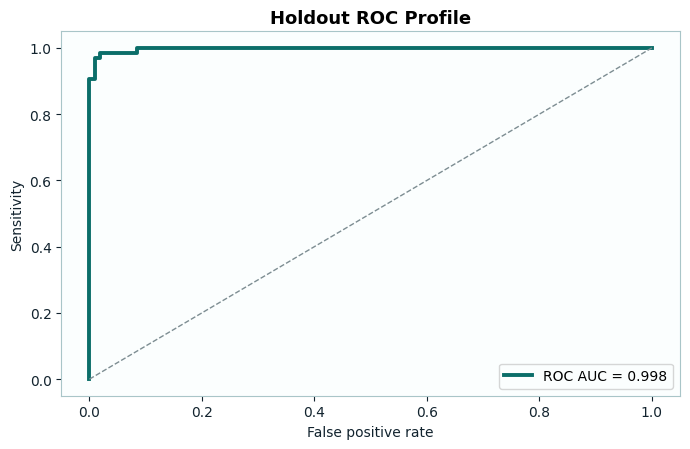

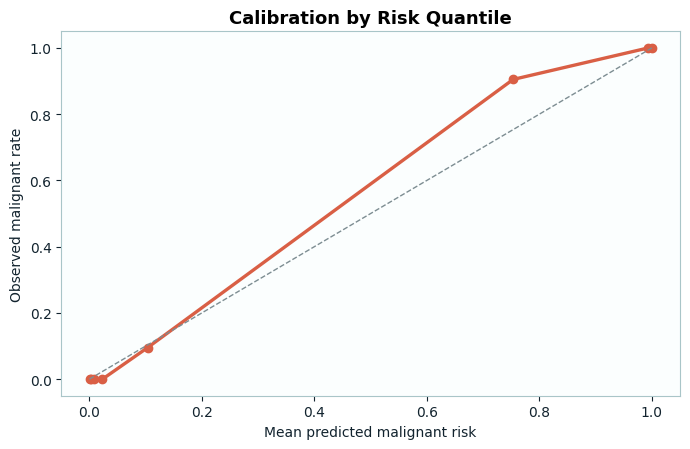

In [6]:
fpr, tpr, _ = roc_curve(y_holdout, p_holdout)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(fpr, tpr, color=HEALTH_TEAL, linewidth=2.8, label=f"ROC AUC = {roc_auc_score(y_holdout, p_holdout):.3f}")
ax.plot([0, 1], [0, 1], color=HEALTH_GRAY, linestyle="--", linewidth=1)
ax.set_title("Holdout ROC Profile")
ax.set_xlabel("False positive rate")
ax.set_ylabel("Sensitivity")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_profile.png", dpi=180)
plt.show()

prob_true, prob_pred = calibration_curve(y_holdout, p_holdout, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(prob_pred, prob_true, color=HEALTH_CORAL, marker="o", linewidth=2.4, markersize=6)
ax.plot([0, 1], [0, 1], color=HEALTH_GRAY, linestyle="--", linewidth=1)
ax.set_title("Calibration by Risk Quantile")
ax.set_xlabel("Mean predicted malignant risk")
ax.set_ylabel("Observed malignant rate")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "calibration_profile.png", dpi=180)
plt.show()


## 7. Review Queue and Risk-Bucket Evidence

The review queue links each holdout record to its score, actual label, governed review flag, and risk bucket. This supports case sampling, reviewer assignment, and post-deployment monitoring.


,review_bucket,records,malignant_rate,mean_score,review_rate
0,low,105,0.009524,0.023750,0.0
1,watch,5,0.600000,0.282041,0.4
2,elevated,8,0.875000,0.661974,1.0
3,critical,53,1.000000,0.988987,1.0


,patient_id,actual_label,predicted_malignant_risk,review_flag,review_bucket
74,BCDR-0393,malignant,0.999973,True,critical
107,BCDR-0280,malignant,0.999940,True,critical
11,BCDR-0181,malignant,0.999929,True,critical
17,BCDR-0343,malignant,0.999884,True,critical
92,BCDR-0118,malignant,0.999861,True,critical
109,BCDR-0018,malignant,0.999786,True,critical
20,BCDR-0162,malignant,0.999746,True,critical
45,BCDR-0083,malignant,0.999724,True,critical
27,BCDR-0025,malignant,0.999715,True,critical
133,BCDR-0468,malignant,0.999550,True,critical


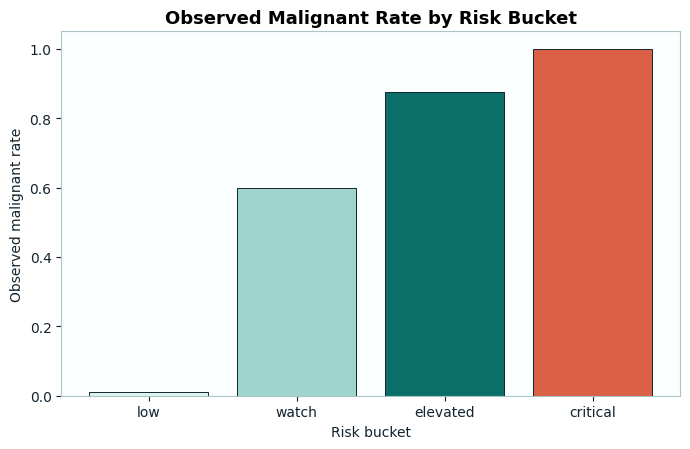

In [7]:
review_queue = pd.DataFrame({
    "patient_id": df.loc[X_holdout.index, "patient_id"].values,
    "actual_label": y_holdout.map({1: "malignant", 0: "benign"}).values,
    "predicted_malignant_risk": p_holdout,
    "review_flag": pred_holdout.astype(bool),
})
review_queue["review_bucket"] = pd.cut(
    review_queue["predicted_malignant_risk"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["low", "watch", "elevated", "critical"],
    include_lowest=True,
)
bucket_summary = review_queue.groupby("review_bucket", observed=True).agg(
    records=("patient_id", "count"),
    malignant_rate=("actual_label", lambda s: (s == "malignant").mean()),
    mean_score=("predicted_malignant_risk", "mean"),
    review_rate=("review_flag", "mean"),
).reset_index()
display(bucket_summary)
display(review_queue.sort_values("predicted_malignant_risk", ascending=False).head(15))
review_queue.to_csv(OUTPUT_DIR / "holdout_review_queue.csv", index=False)
bucket_summary.to_csv(OUTPUT_DIR / "risk_bucket_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.bar(bucket_summary["review_bucket"].astype(str), bucket_summary["malignant_rate"], color=[HEALTH_MINT, "#9fd4cc", HEALTH_TEAL, HEALTH_CORAL], edgecolor=HEALTH_INK, linewidth=.7)
ax.set_title("Observed Malignant Rate by Risk Bucket")
ax.set_xlabel("Risk bucket")
ax.set_ylabel("Observed malignant rate")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "risk_bucket_outcomes.png", dpi=180)
plt.show()


## 8. HUG-IML Pattern Evidence

HUG-IML retains human-readable threshold and interval patterns. The table below ranks patterns by absolute coefficient magnitude to support model review and challenge.


,pattern,coefficient,abs_coefficient
0,"mean texture=[21.52,23.97)",1.336978,1.336978
1,"worst texture=[32.3,49.54)",1.134649,1.134649
2,"worst radius=[16.85,33.13)",0.989677,0.989677
3,"worst concavity=[0.1329,0.1839)",-0.981513,0.981513
4,"worst texture=[12.02,19.53)",-0.922936,0.922936
5,"mean texture=[9.71,15.05)",-0.922439,0.922439
6,"worst concave points=[0.18,0.291)",0.914456,0.914456
7,"worst concavity=[0.07124,0.1329)",-0.861733,0.861733
8,"worst radius=[13.47,16.85)",-0.856564,0.856564
9,"worst radius=[7.93,13.47)",-0.850683,0.850683


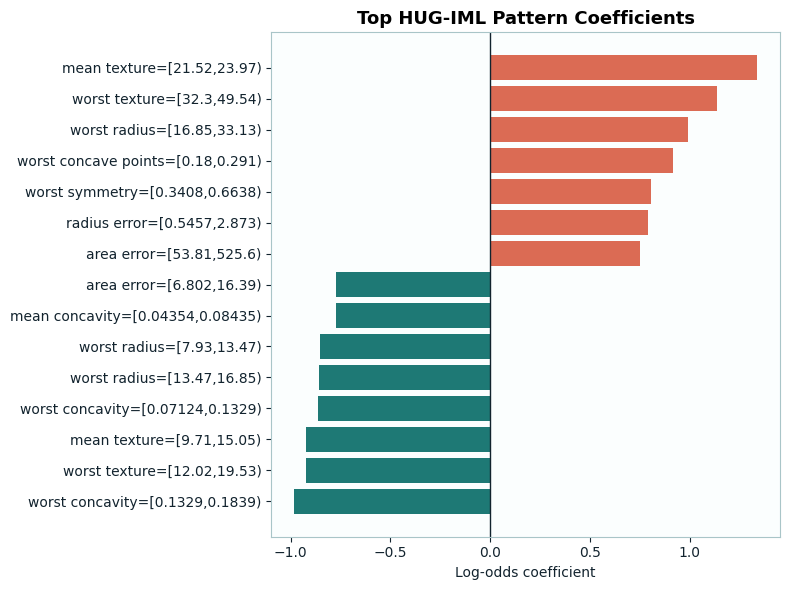

In [8]:
patterns = pd.DataFrame({
    "pattern": model.get_hug_features(),
    "coefficient": model.model_.named_steps["clf"].coef_[0],
})
patterns["abs_coefficient"] = patterns["coefficient"].abs()
patterns = patterns.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
patterns.to_csv(OUTPUT_DIR / "hugiml_pattern_register.csv", index=False)
display(patterns.head(25))

fig, ax = plt.subplots(figsize=(8, 6))
top_patterns = patterns.head(15).sort_values("coefficient")
coef_colors = [HEALTH_CORAL if v > 0 else HEALTH_TEAL for v in top_patterns["coefficient"]]
ax.barh(top_patterns["pattern"], top_patterns["coefficient"], color=coef_colors, alpha=.92)
ax.axvline(0, color=HEALTH_INK, linewidth=1)
ax.set_title("Top HUG-IML Pattern Coefficients")
ax.set_xlabel("Log-odds coefficient")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "top_pattern_coefficients.png", dpi=180)
plt.show()


## 9. Morphology-Strata Safety Review

Because demographic attributes are not present, this is not a protected-class fairness assessment. The review instead asks whether errors concentrate across clinically meaningful morphology strata based on radius and compactness.


In [9]:
def make_morphology_strata(X_frame):
    compactness = pd.qcut(X_frame["mean compactness"], 3, labels=["low compactness", "mid compactness", "high compactness"])
    radius = pd.qcut(X_frame["mean radius"], 3, labels=["small radius", "mid radius", "large radius"])
    return radius.astype(str) + " / " + compactness.astype(str)

strata = make_morphology_strata(X_holdout)
safety_rows = []
for group in sorted(strata.unique()):
    mask = strata == group
    if mask.sum() < 10:
        continue
    ctn, cfp, cfn, ctp = confusion_matrix(y_holdout[mask], pred_holdout[mask], labels=[0, 1]).ravel()
    safety_rows.append({
        "stratum": group,
        "records": int(mask.sum()),
        "malignant_rate": y_holdout[mask].mean(),
        "mean_predicted_risk": float(np.mean(p_holdout[mask])),
        "review_rate": float(pred_holdout[mask].mean()),
        "sensitivity": ctp / max(ctp + cfn, 1),
        "specificity": ctn / max(ctn + cfp, 1),
        "false_negative_count": int(cfn),
        "false_positive_count": int(cfp),
    })
safety_review = pd.DataFrame(safety_rows).sort_values(["false_negative_count", "mean_predicted_risk"], ascending=[False, False])
display(safety_review)
safety_review.to_csv(OUTPUT_DIR / "morphology_strata_safety_review.csv", index=False)


,stratum,records,malignant_rate,mean_predicted_risk,review_rate,sensitivity,specificity,false_negative_count,false_positive_count
2,mid radius / high compactness,13,0.769231,0.631184,0.769231,0.90,0.666667,1,1
4,mid radius / mid compactness,21,0.190476,0.115329,0.142857,0.75,1.000000,1,0
0,large radius / high compactness,39,0.923077,0.928576,0.923077,1.00,1.000000,0,0
1,large radius / mid compactness,13,0.769231,0.743414,0.769231,1.00,1.000000,0,0
3,mid radius / low compactness,23,0.086957,0.083399,0.086957,1.00,1.000000,0,0
6,small radius / mid compactness,23,0.000000,0.023007,0.000000,0.00,1.000000,0,0
5,small radius / low compactness,29,0.000000,0.009652,0.000000,0.00,1.000000,0,0


## 10. Monitoring Indicators and Audit Artifacts

Monitoring focuses on score-distribution drift, review workload, and error concentration. The exported artifacts provide a compact evidence pack for validation, approval, and periodic model review.


In [10]:
def psi(expected, observed, bins=10):
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    exp_counts, _ = np.histogram(expected, bins=edges)
    obs_counts, _ = np.histogram(observed, bins=edges)
    exp_pct = np.maximum(exp_counts / max(exp_counts.sum(), 1), 1e-6)
    obs_pct = np.maximum(obs_counts / max(obs_counts.sum(), 1), 1e-6)
    return float(np.sum((obs_pct - exp_pct) * np.log(obs_pct / exp_pct)))

monitoring = pd.DataFrame({
    "indicator": [
        "train_vs_holdout_score_psi",
        "holdout_review_rate",
        "holdout_false_negative_count",
        "holdout_ece_10_bin",
        "morphology_strata_reviewed",
    ],
    "value": [
        psi(pd.Series(p_train), pd.Series(p_holdout)),
        float(pred_holdout.mean()),
        int(fn),
        expected_calibration_error(y_holdout.to_numpy(), p_holdout, 10),
        int(len(safety_review)),
    ],
    "governance_interpretation": [
        "Low values indicate stable score distributions between development and holdout samples.",
        "Operational review workload implied by the governed safety threshold.",
        "Safety-critical count requiring case review and root-cause analysis.",
        "Calibration gap across ten probability bins.",
        "Number of morphology strata included in concentration review.",
    ],
})
display(monitoring)
monitoring.to_csv(OUTPUT_DIR / "monitoring_indicators.csv", index=False)

summary_payload = {
    "model_name": "hugiml-core HUGIMLClassifierNative",
    "records": int(len(df)),
    "features": int(len(feature_cols)),
    "target_definition": "diagnosis_malignant = 1 for malignant records",
    "roc_auc": float(roc_auc_score(y_holdout, p_holdout)),
    "average_precision": float(average_precision_score(y_holdout, p_holdout)),
    "threshold": float(threshold),
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "sensitivity": float(recall_score(y_holdout, pred_holdout, zero_division=0)),
    "specificity": float(tn / max(tn + fp, 1)),
    "brier_score": float(brier_score_loss(y_holdout, p_holdout)),
    "ece_10_bin": float(expected_calibration_error(y_holdout.to_numpy(), p_holdout, 10)),
    "pattern_count": int(len(patterns)),
    "privacy_note": "audit identifier excluded from modeling; benchmark file contains morphology measurements only",
    "fairness_note": "protected-class fairness cannot be assessed because demographic attributes are not present",
}
(OUTPUT_DIR / "clinical_governance_summary.json").write_text(json.dumps(summary_payload, indent=2))
display(pd.Series(summary_payload, name="value").to_frame())


,indicator,value,governance_interpretation
0,train_vs_holdout_score_psi,0.047009,Low values indicate stable score distributions...
1,holdout_review_rate,0.368421,Operational review workload implied by the gov...
2,holdout_false_negative_count,2.000000,Safety-critical count requiring case review an...
3,holdout_ece_10_bin,0.031412,Calibration gap across ten probability bins.
4,morphology_strata_reviewed,7.000000,Number of morphology strata included in concen...


,value
model_name,hugiml-core HUGIMLClassifierNative
records,569
features,30
target_definition,diagnosis_malignant = 1 for malignant records
roc_auc,0.99781
average_precision,0.996576
threshold,0.3
confusion_matrix,"{'tn': 106, 'fp': 1, 'fn': 2, 'tp': 62}"
sensitivity,0.96875
specificity,0.990654
